# Spotify Trend Analysis

## Objective
Analyze Spotify track data to discover:

- What makes songs popular?
- Which audio features are related?
- Can popularity be predicted?
- Can songs be grouped into meaningful categories?

In [4]:
%pip install pandas matplotlib seaborn numpy scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 903.4 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.0 MB 1.0 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.0 MB 1.0 MB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.0 MB 909.2 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.0 MB 909.2 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.0 MB 909.2 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.0 MB 718.9 kB/s eta 0:00:10
   ------ --------------------------------- 1.3/8.0 MB 718.9 kB/s eta 0:00:10
   ------- -------------------------------- 1.6/8.0 MB 674.3 kB/s eta 0:00:10
   --------- ------------------------------ 1.8/8.0 MB 736.1 kB/s eta 0:00:09
   --------- ----


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [25]:
df = pd.read_csv("data//spotify_tracks.csv")

df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [26]:
df.shape
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  str    
 1   artist_name       232725 non-null  str    
 2   track_name        232724 non-null  str    
 3   track_id          232725 non-null  str    
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  str    
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  str    
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    232725 non-nu

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='str')

In [27]:
df.describe()


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [28]:
df.isnull().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [30]:
df.duplicated().sum()
df = df.drop_duplicates()

In [31]:
df["duration_min"] = df["duration_ms"] / 60000

In [32]:
df["popularity_category"] = pd.cut(
    df["popularity"],
    bins=[0,35,70,100],
    labels=["Low","Medium","High"]
)

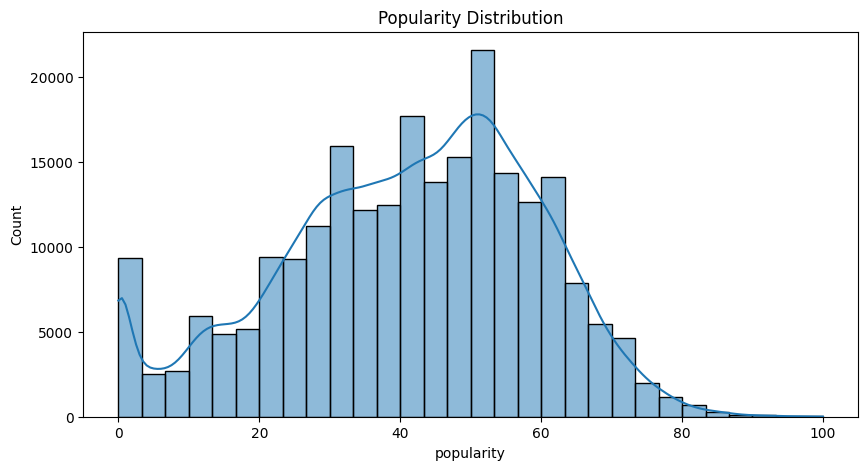

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(df["popularity"], bins=30, kde=True)

plt.title("Popularity Distribution")
plt.show()

Most songs fall in the medium popularity range.
Very highly popular songs are relatively rare.

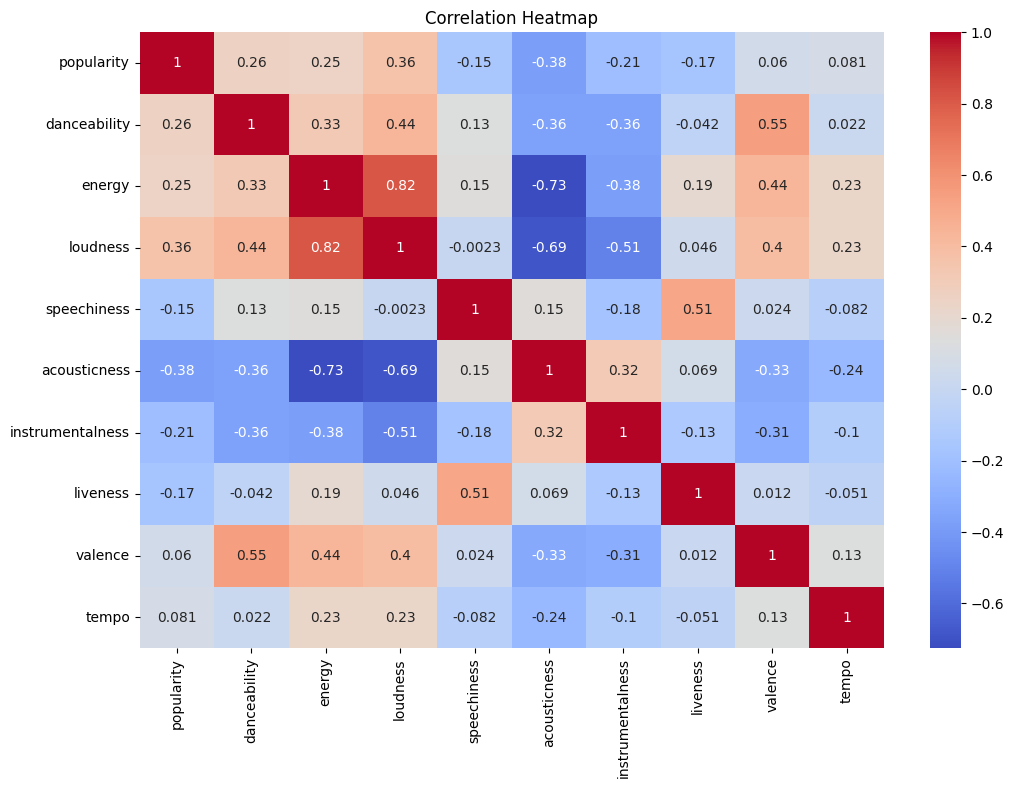

In [34]:
features = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Energy and loudness are strongly correlated.
Acousticness is negatively correlated with energy.

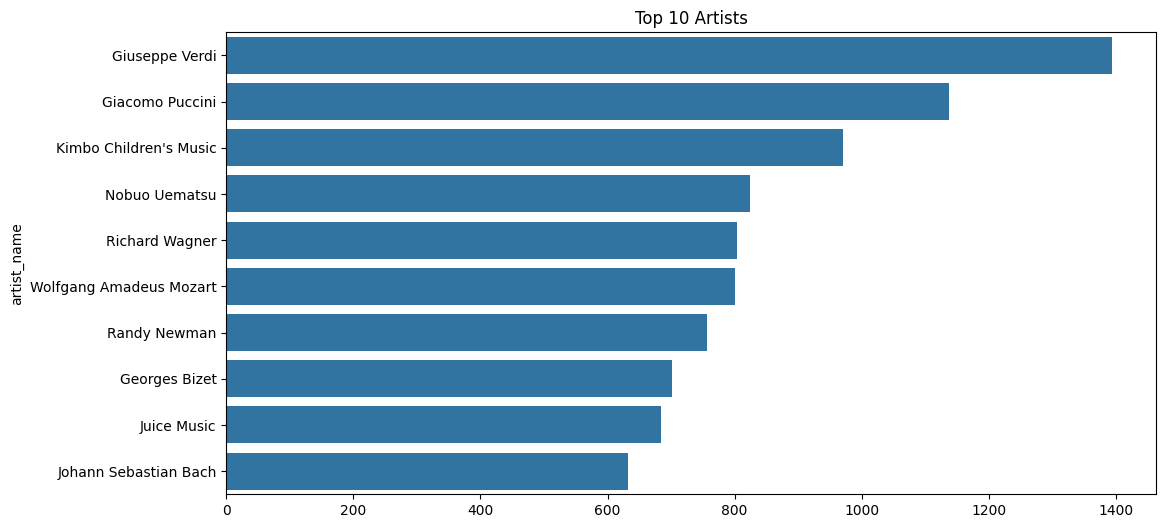

In [35]:
top_artists = (
    df["artist_name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title("Top 10 Artists")
plt.show()

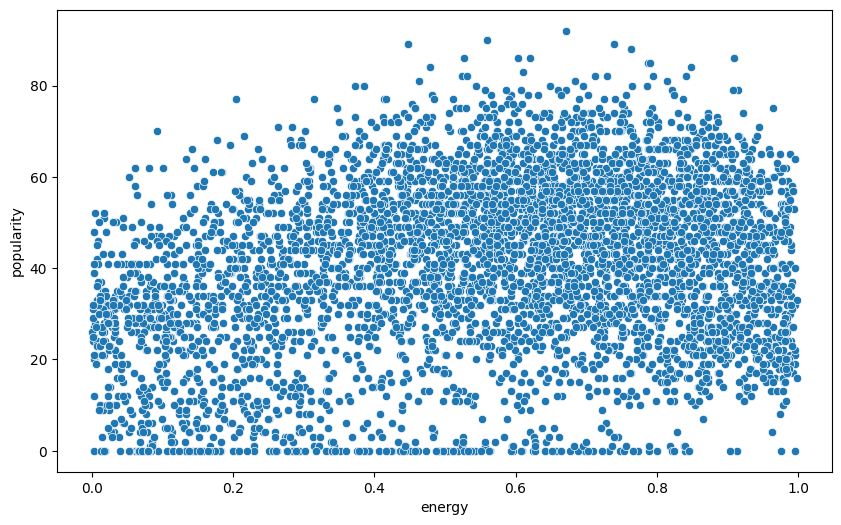

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x="energy",
    y="popularity"
)

plt.show()

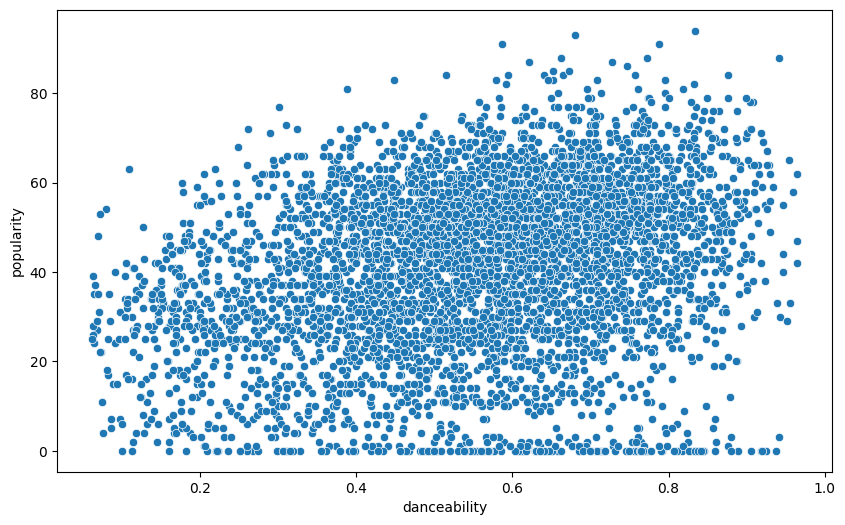

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x="danceability",
    y="popularity"
)

plt.show()

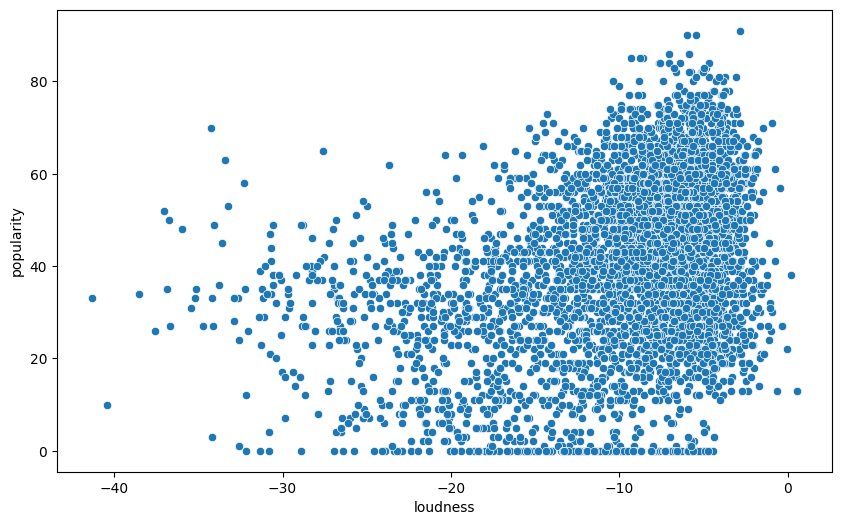

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x="loudness",
    y="popularity"
)

plt.show()

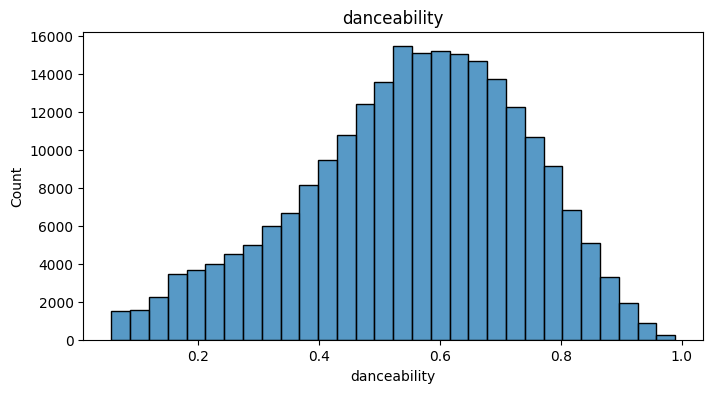

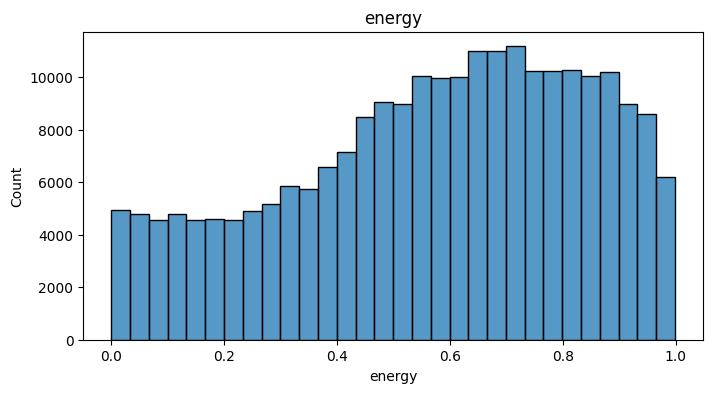

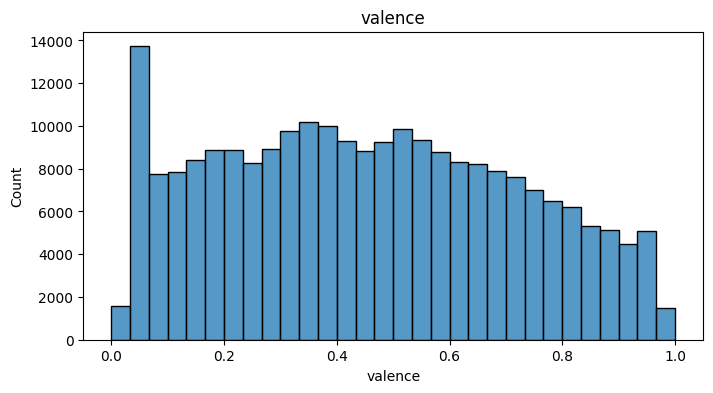

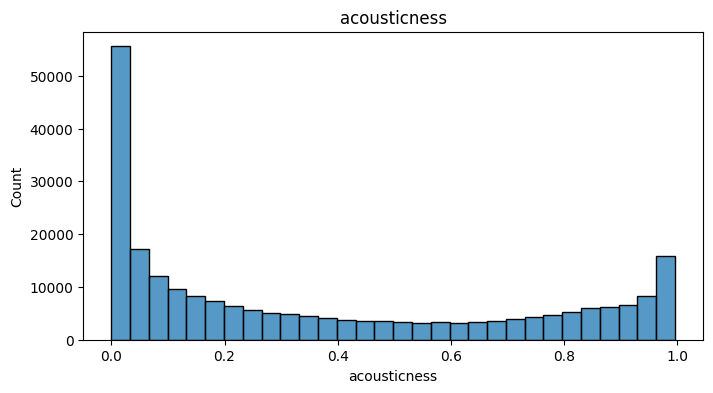

In [39]:
features = [
    "danceability",
    "energy",
    "valence",
    "acousticness"
]

for feature in features:

    plt.figure(figsize=(8,4))

    sns.histplot(df[feature], bins=30)

    plt.title(feature)

    plt.show()

In [40]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]
y = df["popularity"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R²:", r2_score(y_test, pred))

MAE: 12.7740672423882
R²: 0.23328395600765672


In [43]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R²:", r2_score(y_test, pred_rf))

MAE: 8.606020431213029
R²: 0.5576569543903903


In [44]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,acousticness,0.237408
2,loudness,0.114636
3,speechiness,0.111694
7,valence,0.101578
0,danceability,0.097707
1,energy,0.091616
6,liveness,0.086250
8,tempo,0.081361
5,instrumentalness,0.077751


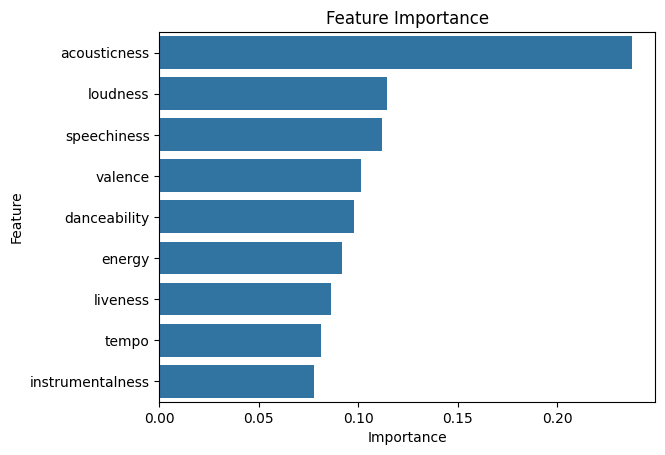

In [45]:
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [46]:
cluster_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness"
]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[cluster_features]
)

In [47]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(
    scaled_data
)

df["cluster"] = clusters

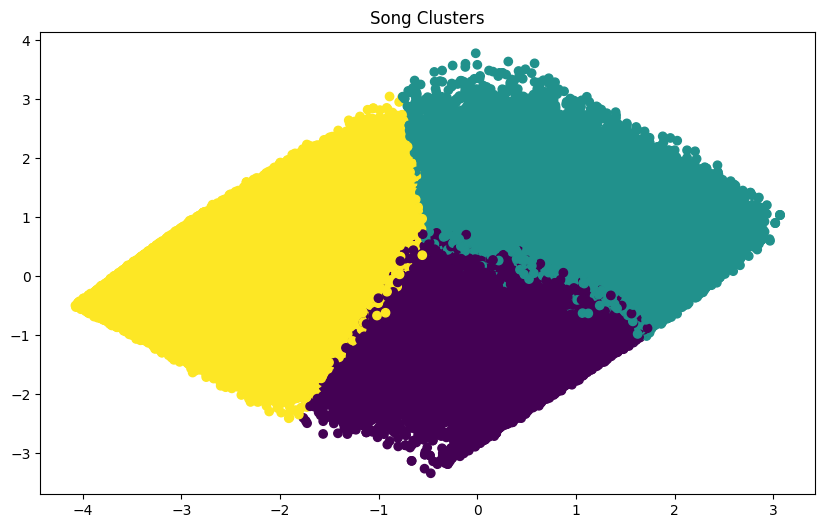

In [48]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_data
)

plt.figure(figsize=(10,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["cluster"]
)

plt.title("Song Clusters")
plt.show()

## Key Findings

- Loudness and energy are the strongest popularity indicators.
- Acoustic songs tend to be less energetic.
- Random Forest outperformed Linear Regression.
- Songs naturally form distinct clusters based on audio features.